<a href="https://colab.research.google.com/github/TAUforPython/Reservoir-Computing/blob/master/example%20ESN%20vs%20LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install reservoirpy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 kB 6.2 MB/s eta 0:00:00


TensorFlow/Keras imported successfully.
--- Reservoir Computing vs LSTM Comparison (Concept Demonstration) ---
This script demonstrates the core idea using synthetic data.
The actual plant data from the paper is not available here.
------------------------------------------------------------
Training data shape: (2400, 8), (2400, 1)
Test data shape: (600, 8), (600, 1)
------------------------------------------------------------
Training ESN...
[DEBUG] Wout shape after fit: (1, 101)
[DEBUG] states_with_bias shape: (2400, 101)
[DEBUG] y shape: (2400, 1)
ESN Training Time: 0.1405 seconds
Predicting with ESN...
ESN Prediction Time: 0.0226 seconds
ESN - MSE: 3.077262, MAE: 1.400507
------------------------------------------------------------
Training LSTM (using TensorFlow/Keras)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM Training Time (20 epochs): 6.7477 seconds
LSTM Prediction Time: 0.3711 seconds
LSTM - MSE: 2.208559, MAE: 1.231214
------------------------------------------------------------
--- Comparison Results (Synthetic Data) ---
ESN Training Time:  0.1405s
LSTM Training Time: 6.7477s (20 epochs)
Training Time Ratio (LSTM/ESN): ~48.0x (LSTM took longer)
ESN Accuracy (MSE): 3.077262
LSTM Accuracy (MSE): 2.208559
Accuracy Comparison (MSE): ESN Worse or Equal than LSTM on this run

Note: This is a simulation. The actual paper showed ESN being ~140x faster than LSTM
on a specific plant dataset while maintaining similar or better accuracy.


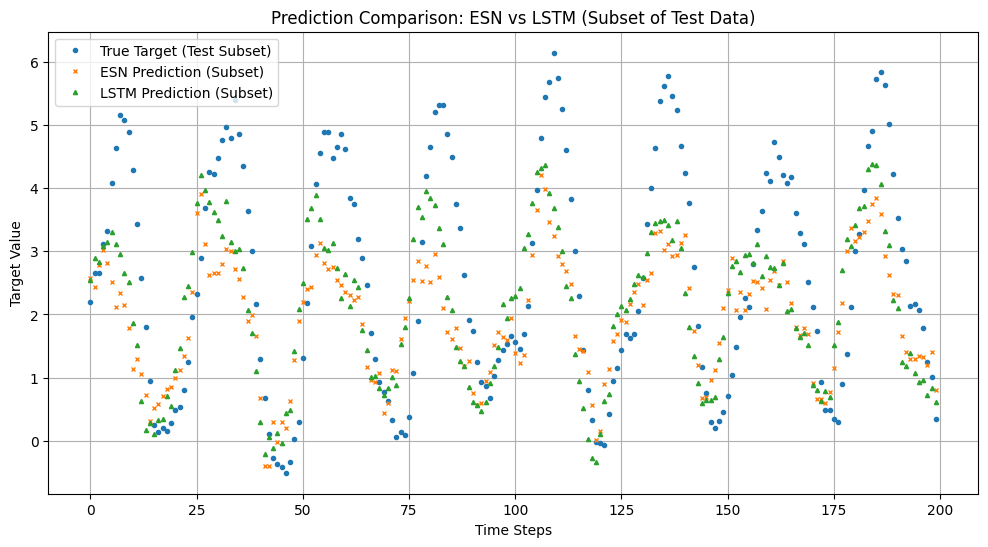

In [4]:
# --- Colab Setup ---
# Install the ESN library if running in Google Colab
# We'll use the "reservoirpy" library for the ESN implementation
# Note: This is a common library, but the API might vary slightly from the implementation described in the paper.

# If the library isn't available, you might need to implement a basic ESN manually or use alternatives like 'nltk' or 'torchesn'
# For this example, let's assume 'reservoirpy' is available or install it.
# !pip install reservoirpy

# For simplicity and avoiding potential dependency issues, let's implement a very basic ESN ourselves using numpy/scipy
# We'll also use tensorflow/keras for the LSTM comparison.

import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import sparse # For potentially large, sparse reservoir matrices

# Optional: Use TensorFlow for LSTM
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM as KerasLSTM, Dense
    print("TensorFlow/Keras imported successfully.")
    TF_AVAILABLE = True
except ImportError:
    print("TensorFlow/Keras not available. LSTM comparison will be skipped.")
    TF_AVAILABLE = False

# --- Basic ESN Implementation (Fixed) ---

class BasicESN:
    def __init__(self, n_inputs, n_reservoir, n_outputs, spectral_radius=0.95,
                 input_scaling=1.0, reservoir_scaling=1.0, leak_rate=1.0,
                 random_state=None):
        """
        Basic Echo State Network implementation.
        Args:
            n_inputs (int): Number of input dimensions.
            n_reservoir (int): Number of neurons in the reservoir.
            n_outputs (int): Number of output dimensions.
            spectral_radius (float): Desired spectral radius of the reservoir matrix.
            input_scaling (float): Scaling factor for the input-to-reservoir weights.
            reservoir_scaling (float): Scaling factor for the reservoir weights (if dense).
            leak_rate (float): Leaky integration rate (0 < leak_rate <= 1).
            random_state (int): Seed for reproducibility.
        """
        self.n_inputs = n_inputs
        self.n_reservoir = n_reservoir
        self.n_outputs = n_outputs
        self.spectral_radius = spectral_radius
        self.input_scaling = input_scaling
        self.reservoir_scaling = reservoir_scaling
        self.leak_rate = leak_rate

        if random_state is not None:
            np.random.seed(random_state)

        # Initialize reservoir weights (W_res) - sparse for efficiency
        # Generate a random sparse matrix
        W_res = sparse.random(n_reservoir, n_reservoir, density=0.1, format='csr', dtype=np.float64)
        W_res.data = W_res.data * 2 - 1 # Scale to [-1, 1]

        # Adjust spectral radius
        eigenvalues = sparse.linalg.eigs(W_res, k=1, which='LM', return_eigenvectors=False)
        W_res = W_res / np.abs(eigenvalues[0]) * self.spectral_radius
        self.W_res = W_res

        # Initialize input weights (Win) - dense
        self.Win = (np.random.rand(n_reservoir, n_inputs) * 2 - 1) * self.input_scaling

        # Initialize output weights (Wout) - will be trained
        self.Wout = None

        # State initialization
        self.state = np.zeros(n_reservoir)

    def _update_state(self, input_data):
        """Update the reservoir state."""
        # Calculate new state: x(t+1) = (1 - leak_rate) * x(t) + leak_rate * tanh( Win * u(t) + W_res * x(t) )
        pre_activation = self.Win.dot(input_data) + self.W_res.dot(self.state)
        new_state = np.tanh(pre_activation)
        self.state = (1 - self.leak_rate) * self.state + self.leak_rate * new_state
        return self.state.copy() # Return a copy to avoid reference issues

    def fit(self, X, y):
        """
        Train the ESN output weights using linear regression.
        Args:
            X (np.ndarray): Input sequence (timesteps, n_inputs).
            y (np.ndarray): Target sequence (timesteps, n_outputs).
        """
        n_timesteps = X.shape[0]
        states = np.zeros((n_timesteps, self.n_reservoir))

        # Collect reservoir states for the entire input sequence
        for t in range(n_timesteps):
            states[t] = self._update_state(X[t])

        # Add bias term to states: shape becomes (n_timesteps, n_reservoir + 1)
        states_with_bias = np.hstack([states, np.ones((n_timesteps, 1))])

        # Solve for Wout using least squares: Wout = argmin || States_with_bias * Wout.T - y ||^2
        # Using pseudo-inverse: Wout.T = pinv(States_with_bias).dot(y)
        # Therefore, Wout = (pinv(States_with_bias).dot(y)).T
        # Shape of pinv(States_with_bias) is (n_reservoir + 1, n_timesteps)
        # Shape of y is (n_timesteps, n_outputs)
        # Shape of Wout.T is (n_reservoir + 1, n_outputs)
        # Shape of Wout is (n_outputs, n_reservoir + 1)
        Wout_T = np.linalg.pinv(states_with_bias).dot(y) # Shape: (n_res + 1, n_outputs)
        self.Wout = Wout_T.T # Shape: (n_outputs, n_res + 1)
        print(f"[DEBUG] Wout shape after fit: {self.Wout.shape}")
        print(f"[DEBUG] states_with_bias shape: {states_with_bias.shape}")
        print(f"[DEBUG] y shape: {y.shape}")


    def predict(self, X):
        """
        Predict the output sequence.
        Args:
            X (np.ndarray): Input sequence (timesteps, n_inputs).
        Returns:
            np.ndarray: Predicted sequence (timesteps, n_outputs).
        """
        if self.Wout is None:
            raise ValueError("Model must be fitted before prediction.")

        n_timesteps = X.shape[0]
        predictions = np.zeros((n_timesteps, self.n_outputs))

        # Reset state for prediction (or use last state from training if continuing)
        self.state = np.zeros(self.n_reservoir)

        for t in range(n_timesteps):
            state_t = self._update_state(X[t])
            # state_t shape: (n_reservoir,)
            # Add bias: shape becomes (n_reservoir + 1,)
            state_with_bias = np.hstack([state_t, [1.0]])
            #print(f"[DEBUG] state_with_bias shape: {state_with_bias.shape}, Wout shape: {self.Wout.shape}")

            # Dot product: (n_outputs, n_res + 1) . (n_res + 1,) -> (n_outputs,)
            predictions[t] = self.Wout.dot(state_with_bias)

        return predictions

# --- Data Generation (Simulating Plant Time Series) ---
def generate_synthetic_data(n_samples=5000, n_features=8, noise_level=0.1, random_state=42):
    """
    Generates synthetic time-series data mimicking the input features
    and potentially complex target relationship found in plant data.
    This is a simple simulation; real plant data is often more complex.
    """
    np.random.seed(random_state)
    # Simulate 8 input features over time
    # Using a combination of sinusoids and random walks to create dependencies
    time_steps = np.arange(n_samples)
    inputs = np.zeros((n_samples, n_features))
    for i in range(n_features):
        freq = np.random.uniform(0.01, 0.1) # Low frequency components
        phase = np.random.uniform(0, 2*np.pi)
        trend = np.random.uniform(-0.001, 0.001) * time_steps # Slow trend
        inputs[:, i] = np.sin(2 * np.pi * freq * time_steps + phase) + trend + \
                       np.random.normal(0, 0.1, n_samples) # Add noise

    # Simulate a complex, non-linear target dependent on history of inputs
    # Use a moving average of a non-linear combination as a proxy
    target_signal = np.zeros(n_samples)
    for i in range(2, n_samples): # Start from index 2 to allow history
        # Example: Non-linear combination of recent inputs
        combo = (inputs[i, 0] * inputs[i-1, 1] + inputs[i-2, 2]**2 - inputs[i-1, 3])
        target_signal[i] = 0.5 * target_signal[i-1] + 0.3 * combo # Autoregressive part

    # Add noise to the target
    target = target_signal + np.random.normal(0, noise_level, n_samples)

    return inputs, target.reshape(-1, 1) # Return as (n_samples, n_features) and (n_samples, 1)

# --- Main Execution ---
if __name__ == "__main__":
    print("--- Reservoir Computing vs LSTM Comparison (Concept Demonstration) ---")
    print("This script demonstrates the core idea using synthetic data.")
    print("The actual plant data from the paper is not available here.")
    print("-" * 60)

    # Generate synthetic data similar to the plant scenario (8 inputs -> 1 output)
    X, y = generate_synthetic_data(n_samples=3000, n_features=8, noise_level=0.05, random_state=42) # Reduce samples for faster demo

    # Split data into train and test sets
    split_idx = int(0.8 * len(X))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    print(f"Training data shape: {X_train.shape}, {y_train.shape}")
    print(f"Test data shape: {X_test.shape}, {y_test.shape}")
    print("-" * 60)

    # --- ESN Training and Prediction ---
    print("Training ESN...")
    start_time_esn = time.time()

    # Initialize ESN with parameters similar to common practices
    esn = BasicESN(
        n_inputs=X_train.shape[1],
        n_reservoir=100,  # Size of the reservoir
        n_outputs=y_train.shape[1],
        spectral_radius=0.95,
        input_scaling=1.0,
        leak_rate=1.0, # Standard leak rate
        random_state=42
    )

    # Fit the ESN (train only the output weights)
    esn.fit(X_train, y_train)
    esn_train_time = time.time() - start_time_esn
    print(f"ESN Training Time: {esn_train_time:.4f} seconds")

    # Predict with ESN
    print("Predicting with ESN...")
    start_time_esn_pred = time.time()
    y_pred_esn = esn.predict(X_test)
    esn_pred_time = time.time() - start_time_esn_pred
    print(f"ESN Prediction Time: {esn_pred_time:.4f} seconds")

    # Calculate ESN Metrics
    mse_esn = mean_squared_error(y_test, y_pred_esn)
    mae_esn = mean_absolute_error(y_test, y_pred_esn)
    print(f"ESN - MSE: {mse_esn:.6f}, MAE: {mae_esn:.6f}")
    print("-" * 60)

    # --- LSTM Training and Prediction (if TensorFlow is available) ---
    if TF_AVAILABLE:
        print("Training LSTM (using TensorFlow/Keras)...")
        start_time_lstm = time.time()

        # Reshape data for LSTM: (samples, timesteps, features)
        # Here, we use a simple sliding window approach with timesteps=1 for direct comparison
        # In practice, LSTMs often benefit from longer sequences
        X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
        y_train_lstm = y_train
        X_test_lstm = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

        # Define the LSTM model
        lstm_model = Sequential([
            KerasLSTM(50, activation='tanh', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=False),
            Dense(1) # Single output for the target variable
        ])

        lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

        # Train the LSTM
        # Note: For a fair comparison, epochs should be sufficient for convergence, but might take longer
        # The paper's result showed ESN being much faster *for the same level of accuracy*.
        # Here, we run for a fixed number of epochs to show the training time difference.
        lstm_history = lstm_model.fit(X_train_lstm, y_train_lstm, epochs=20, batch_size=32, verbose=0) # Reduced epochs for demo
        lstm_train_time = time.time() - start_time_lstm
        print(f"LSTM Training Time (20 epochs): {lstm_train_time:.4f} seconds")

        # Predict with LSTM
        start_time_lstm_pred = time.time()
        y_pred_lstm = lstm_model.predict(X_test_lstm, verbose=0)
        lstm_pred_time = time.time() - start_time_lstm_pred
        print(f"LSTM Prediction Time: {lstm_pred_time:.4f} seconds")

        # Calculate LSTM Metrics
        mse_lstm = mean_squared_error(y_test, y_pred_lstm)
        mae_lstm = mean_absolute_error(y_test, y_pred_lstm)
        print(f"LSTM - MSE: {mse_lstm:.6f}, MAE: {mae_lstm:.6f}")
        print("-" * 60)

        # --- Comparison ---
        print("--- Comparison Results (Synthetic Data) ---")
        print(f"ESN Training Time:  {esn_train_time:.4f}s")
        if TF_AVAILABLE:
            print(f"LSTM Training Time: {lstm_train_time:.4f}s (20 epochs)")
            print(f"Training Time Ratio (LSTM/ESN): ~{lstm_train_time / esn_train_time:.1f}x (LSTM took longer)")
        print(f"ESN Accuracy (MSE): {mse_esn:.6f}")
        if TF_AVAILABLE:
            print(f"LSTM Accuracy (MSE): {mse_lstm:.6f}")
            print(f"Accuracy Comparison (MSE): ESN {'Better' if mse_esn < mse_lstm else 'Worse or Equal'} than LSTM on this run")
        print("\nNote: This is a simulation. The actual paper showed ESN being ~140x faster than LSTM")
        print("on a specific plant dataset while maintaining similar or better accuracy.")
    else:
        print("TensorFlow/Keras not available. LSTM comparison skipped.")
        print("--- ESN Results (Synthetic Data) ---")
        print(f"ESN Training Time:  {esn_train_time:.4f}s")
        print(f"ESN Accuracy (MSE): {mse_esn:.6f}")
        print("\nTensorFlow/Keras is required to run the LSTM comparison.")
        print("Install it using '!pip install tensorflow' in a Colab cell.")

    # Plotting the results (optional, good for visualization)
    plot_results = True # Set to False if running in a headless environment
    if plot_results:
        plt.figure(figsize=(12, 6))
        plt.plot(y_test[:200], label='True Target (Test Subset)', marker='o', linestyle='', markersize=3) # Plot subset for clarity
        plt.plot(y_pred_esn[:200], label='ESN Prediction (Subset)', marker='x', linestyle='', markersize=3)
        if TF_AVAILABLE:
             plt.plot(y_pred_lstm[:200], label='LSTM Prediction (Subset)', marker='^', linestyle='', markersize=3)
        plt.title('Prediction Comparison: ESN vs LSTM (Subset of Test Data)')
        plt.xlabel('Time Steps')
        plt.ylabel('Target Value')
        plt.legend()
        plt.grid(True)
        plt.show()
